# Machine Learning Foundation

## Section 2, Part d:  Regularization and Gradient Descent


## Introducción

Comenzaremos con un breve tutorial sobre regresión, características polinómicas y regularización basado en un conjunto de datos dispersos muy simple que contiene una columna de datos `x` y datos `y` ruidosos asociados. El archivo de datos se llama `X_Y_Sinusoid_Data.csv`.

## Pregunta 1

* Importar los datos.

* Generar también aproximadamente 100 puntos de datos x equidistantes en el rango de 0 a 1. Con estos puntos, calcular los datos y, que representan la "verdad fundamental" (la función real) de la ecuación: $y = sin(2\pi x)$

* Representar gráficamente los datos dispersos (`x` vs `y`) y los datos calculados ("reales").

In [1]:
#!pip install pandas
#!pip install scikit-learn
#!pip install seaborn
#!pip install matplotlib

In [3]:
# Surpress warnings from using older version of sklearn:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [5]:
import pandas as pd
import numpy as np


np.set_printoptions(suppress=True) #suppress=True evita la notación científica.

data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/X_Y_Sinusoid_Data.csv")
data.head()

X_real = np.linspace(0, 1.0, 100)
Y_real = np.sin(2 * np.pi * X_real)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Visualización

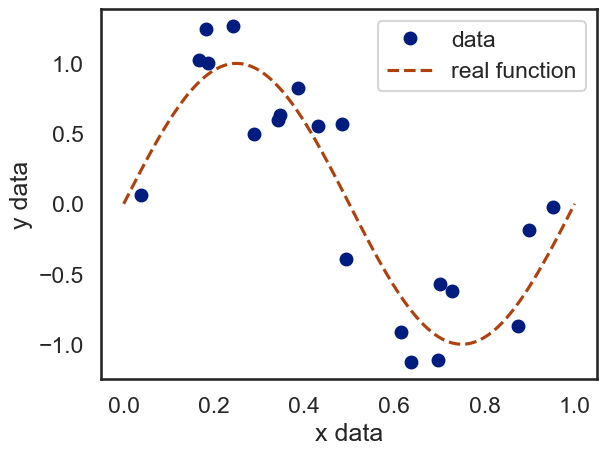

In [9]:
sns.set_style('white')
sns.set_context('talk')
sns.set_palette('dark')

# Plot of the noisy (sparse)
ax = data.set_index('x')['y'].plot(ls='', marker='o', label='data')
ax.plot(X_real, Y_real, ls='--', marker='', label='real function')

ax.legend()
ax.set(xlabel='x data', ylabel='y data');


## Pregunta 2

* Utilizando la clase `PolynomialFeatures` de la biblioteca de preprocesamiento de Scikit-learn, cree características polinómicas de orden 20.
* Ajuste estos datos mediante regresión lineal.
* Grafique el valor predicho resultante comparándolo con los datos calculados.

Tenga en cuenta que `PolynomialFeatures` requiere un marco de datos (con una columna, no una serie) o un array 2D de dimensión (`X`, 1), donde `X` es la longitud.

In [13]:
data.shape

(20, 2)

In [15]:
data

,x,y
0,0.038571,0.066391
1,0.166776,1.027483
2,0.183153,1.245302
3,0.187359,1.004781
4,0.243116,1.264121
5,0.289299,0.498330
6,0.342805,0.597502
7,0.345499,0.629410
8,0.386477,0.822705
9,0.430047,0.557581


Importamos las librerías que se van a ocupar.

In [17]:
# Importamos las herramientas necesarias
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

### Modelo

Definimos el grado del polinomio (grados altos pueden producir sobreajuste)

In [19]:
# Definimos el grado del polinomio.
# Grados altos pueden producir sobreajuste.
degree = 20
pf = PolynomialFeatures(degree)

Creamos el **modelo de regresión lineal** que se ajustará sobre las características polinómicas

In [22]:
lr = LinearRegression()

Extraemos los datos $x$ y $y$ desde el dataframe 

In [24]:
# X_data debe ser un DataFrame (por eso usamos doble corchete).
X_data = data[['x']]
Y_data = data['y']

Se revisa el tipo de datos que generamos

In [26]:
print(f"type X_data: {type(X_data)}") 
print(f"type X_data: {type(Y_data)}") 

type X_data: <class 'pandas.core.frame.DataFrame'>
type X_data: <class 'pandas.core.series.Series'>


Generamos las características polinómicas: 1, x, $x^2$, $\ldots $ , $x^{20}$

In [28]:
# Generamos las características polinómicas: 1, x, x^2, ..., x^20
X_poly = pf.fit_transform(X_data)

Observamos los primeros dos valores de **X_data** sin transformar y con la transformación Polinomica

In [30]:
X_data.head(2)

,x
0,0.038571
1,0.166776


In [32]:
print(X_poly[0:2])

[[1.         0.03857092 0.00148772 0.00005738 0.00000221 0.00000009
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]
 [1.         0.16677635 0.02781435 0.00463878 0.00077364 0.00012902
  0.00002152 0.00000359 0.0000006  0.0000001  0.00000002 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.        ]]


Se ajusta el modelo usando las características polinomicas 

In [36]:
lr = lr.fit(X_poly, Y_data)
lr

LinearRegression()

Generamos predicciones utilizando el mismo conjunto

In [38]:
Y_pred = lr.predict(X_poly)
Y_pred

array([ 0.06347656,  1.02783203,  1.23876953,  1.00585938,  1.26367188,
        0.49853516,  0.55712891,  0.66894531,  0.81884766,  0.55957031,
        0.56054688, -0.39160156, -0.91259766, -1.13085938, -1.10742188,
       -0.57226562, -0.62011719, -0.8671875 , -0.19140625, -0.01171875])

###  Visualización

#### Gráfico datos observados

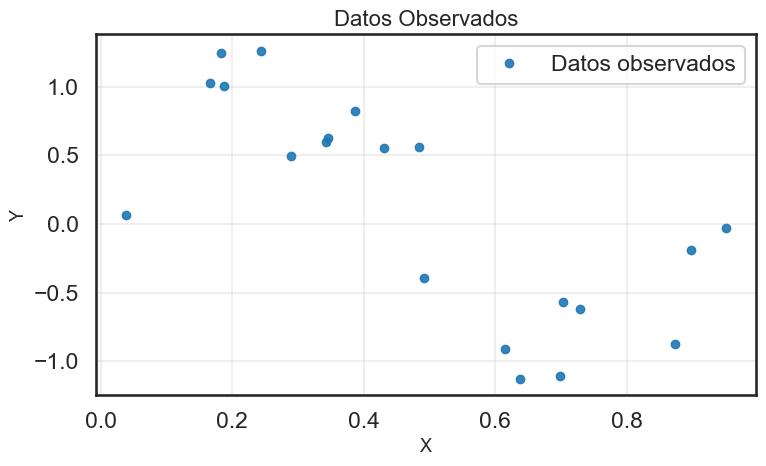

In [40]:
plt.figure(figsize=(8,5))
plt.plot(X_data, Y_data, marker='o', ls='', color='tab:blue',
         label='Datos observados', alpha=0.9, markersize=6)

plt.title("Datos Observados", fontsize=16)
plt.xlabel("X", fontsize=13)
plt.ylabel("Y", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Gráficos datos reales

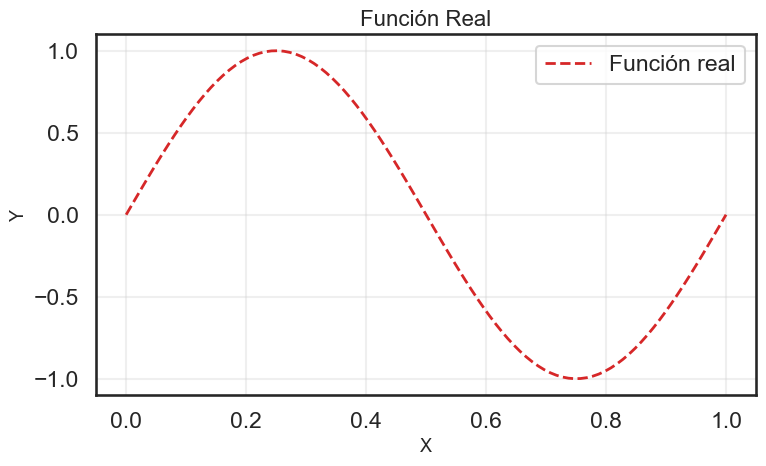

In [42]:
plt.figure(figsize=(8,5))
plt.plot(
    X_real, Y_real, 
    linestyle='--', 
    linewidth=2, 
    color='tab:red',
    label='Función real'
)

plt.title("Función Real", fontsize=16)
plt.xlabel("X", fontsize=13)
plt.ylabel("Y", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### Gráfico datos predichos

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    X_data, Y_pred,
    marker='^',
    markersize=6,
    linestyle='-',
    linewidth=1.5,
    color='tab:green',
    alpha=0.7,
    label='Predicciones (modelo polinomial)'
)

plt.title("Predicciones del Modelo Polinomial", fontsize=16)
plt.xlabel("X", fontsize=13)
plt.ylabel("Y Predicho", fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


#### Gráfico final.

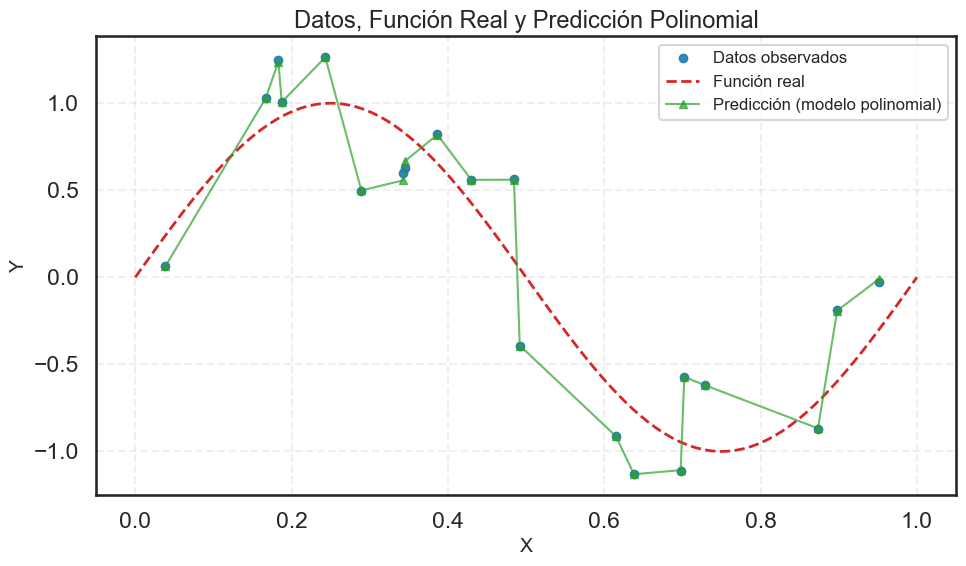

In [44]:
plt.figure(figsize=(10,6))

# --- Datos reales ---
plt.plot(
    X_data, Y_data,
    marker='o',
    linestyle='',
    color='tab:blue',
    markersize=6,
    alpha=0.9,
    label='Datos observados'
)

# --- Función real ---
plt.plot(
    X_real, Y_real,
    linestyle='--',
    linewidth=2,
    color='tab:red',
    label='Función real'
)

# --- Predicciones ---
plt.plot(
    X_data, Y_pred,
    marker='^',
    linestyle='-',
    linewidth=1.5,
    markersize=6,
    color='tab:green',
    alpha=0.7,
    label='Predicción (modelo polinomial)'
)

# --- Título y ejes ---
plt.title("Datos, Función Real y Predicción Polinomial", fontsize=17)
plt.xlabel("X", fontsize=14)
plt.ylabel("Y", fontsize=14)

# --- Cuadrícula y leyenda ---
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


## Pregunta 3

* Realice la regresión utilizando los datos con características polinómicas mediante la regresión de cresta ($\alpha$=0,001) y la regresión Lasso ($\alpha$=0,0001).
* Grafique los resultados, como se hizo en la Pregunta 1.
* También grafique la magnitud de los coeficientes obtenidos de estas regresiones y compárelas con los obtenidos de la regresión lineal en la pregunta anterior. Los coeficientes de la regresión lineal probablemente necesitarán un gráfico aparte (o su propio eje y) debido a su gran magnitud.

¿Qué le indica la magnitud comparativamente grande de los datos sobre el papel de la regularización?


In [46]:
# Silenciamos las advertencias de sklearn relacionadas con regularización.
# Esto ayuda a mantener la salida limpia, especialmente cuando Lasso genera warnings
# si detecta características que pueden ser reducidas a cero.
import warnings
warnings.filterwarnings('ignore', module='sklearn')

from sklearn.linear_model import Ridge, Lasso

### Modelos de regresión regularizada

#### Ridge Regression (L2)

In [48]:
# Penaliza los coeficientes grandes suavemente, evitando sobreajuste.
rr = Ridge(alpha=0.001)
rr = rr.fit(X_poly, Y_data)
Y_pred_rr = rr.predict(X_poly)
Y_pred_rr

array([ 0.4545711 ,  0.88873384,  0.91193533,  0.916696  ,  0.93359069,
        0.88329744,  0.75532747,  0.74700638,  0.59979815,  0.40492901,
        0.118214  ,  0.07640707, -0.62048924, -0.73276485, -0.94932272,
       -0.96057684, -1.00497984, -0.56068483, -0.38579856, -0.01912446])

#### Lasso Regression (L1)

In [50]:
# Lasso Regression (L1)
# Puede reducir coeficientes exactamente a cero, creando modelos más simples.
lassor = Lasso(alpha=0.0001)
lassor = lassor.fit(X_poly, Y_data)
Y_pred_lr = lassor.predict(X_poly)
Y_pred_lr

array([ 0.35126961,  0.9211695 ,  0.9494539 ,  0.95516874,  0.97317946,
        0.91161532,  0.76346518,  0.75404761,  0.59047931,  0.38096869,
        0.0838454 ,  0.04147324, -0.63473538, -0.73875111, -0.93532622,
       -0.94536262, -0.98459531, -0.57273313, -0.40214631, -0.00572072])

### Gráficas de modelos

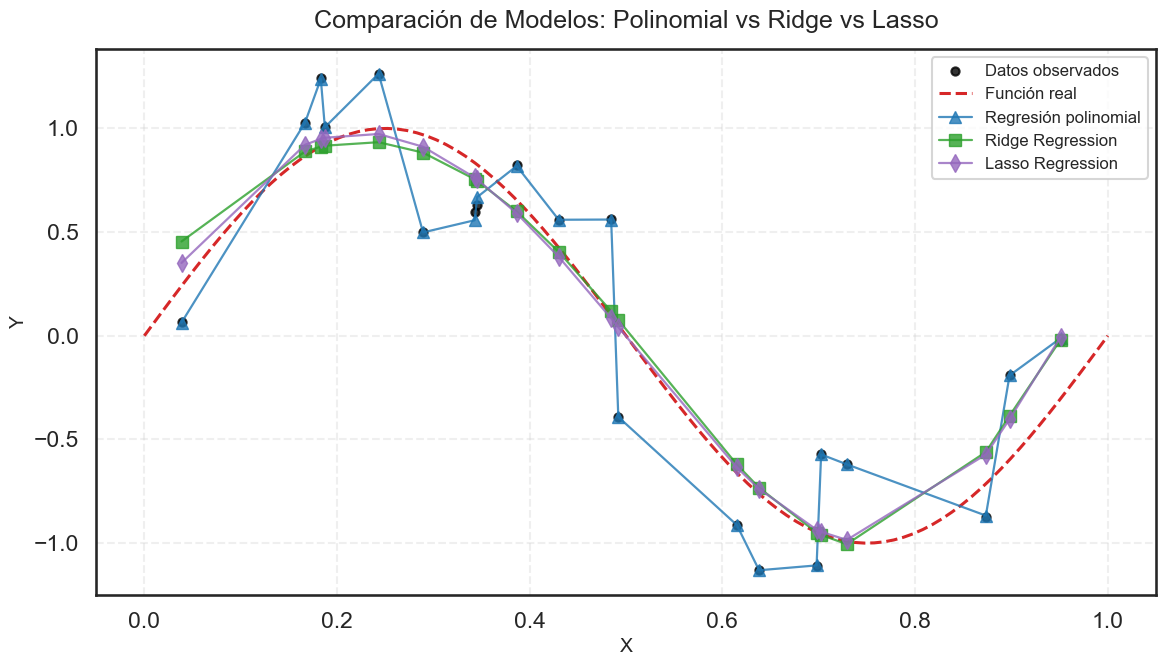

In [52]:
plt.figure(figsize=(12,7))

# ----------------------------------------------------------
#                    Datos Reales
# ----------------------------------------------------------
plt.scatter(
    X_data, Y_data,
    color='black',
    s=35,
    alpha=0.8,
    label='Datos observados'
)

# ----------------------------------------------------------
#                    Función Real
# ----------------------------------------------------------
plt.plot(
    X_real, Y_real,
    linestyle='--',
    linewidth=2.2,
    color='tab:red',
    label='Función real'
)

# ----------------------------------------------------------
#                    Predicción: Sin Regularización
# ----------------------------------------------------------
plt.plot(
    X_data, Y_pred,
    marker='^',
    linestyle='-',
    linewidth=1.6,
    color='tab:blue',
    alpha=0.8,
    label='Regresión polinomial'
)

# ----------------------------------------------------------
#                    Predicción: Ridge
# ----------------------------------------------------------
plt.plot(
    X_data, Y_pred_rr,
    marker='s',
    linestyle='-',
    linewidth=1.6,
    color='tab:green',
    alpha=0.8,
    label='Ridge Regression'
)

# ----------------------------------------------------------
#                    Predicción: Lasso
# ----------------------------------------------------------
plt.plot(
    X_data, Y_pred_lr,
    marker='d',
    linestyle='-',
    linewidth=1.6,
    color='tab:purple',
    alpha=0.8,
    label='Lasso Regression'
)

# ----------------------------------------------------------
#                    Estética general
# ----------------------------------------------------------
plt.title(
    "Comparación de Modelos: Polinomial vs Ridge vs Lasso",
    fontsize=18,
    pad=15
)

plt.xlabel("X", fontsize=14)
plt.ylabel("Y", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.3)

plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()



### Análisis de los coeficientes.

In [54]:
# Creamos un DataFrame vacío para almacenar los coeficientes de cada modelo
coefficients = pd.DataFrame()

Coeficientes del modelo de regresión polinomial estándar (sin regularización)

In [56]:
coefficients['linear regression'] = lr.coef_.ravel() # ravel() convierte el array en un vector 1D

Coeficientes del modelo Ridge (regularización L2)

In [58]:
coefficients['ridge regression'] = rr.coef_.ravel()

Coeficientes del modelo Lasso (regularización L1)

In [60]:
coefficients['lasso regression'] = lassor.coef_.ravel()

Se muestram los coeficientes de los modelos

In [62]:
coefficients.head(5)

,linear regression,ridge regression,lasso regression
0,-3.649902e+12,0.000000,0.000000
1,1.622914e+07,6.065176,8.490500
2,-4.670025e+08,-12.429635,-20.176708
3,7.694716e+09,-4.070127,1.641353
4,-8.286099e+10,2.307194,5.698488


Tomamos el valor absoluto de todos los coeficientes. Esto es útil para comparar las magnitudes sin importar el signo.

In [64]:
coefficients = coefficients.applymap(abs)
coefficients.head(5)

,linear regression,ridge regression,lasso regression
0,3.649902e+12,0.000000,0.000000
1,1.622914e+07,6.065176,8.490500
2,4.670025e+08,12.429635,20.176708
3,7.694716e+09,4.070127,1.641353
4,8.286099e+10,2.307194,5.698488


Mostramos estadísticas descriptivas de los coeficientes. 

Esto permite ver la gran diferencia de escala entre regresión no regularizada y las regresiones regularizadas (ridge y lasso)

In [66]:
coefficients.describe()

,linear regression,ridge regression,lasso regression
count,2.100000e+01,21.000000,21.000000
mean,5.783911e+13,2.169397,2.167284
std,6.038244e+13,2.900278,4.706731
min,1.622914e+07,0.000000,0.000000
25%,3.421984e+12,0.467578,0.000000
50%,3.623240e+13,1.017272,0.252181
75%,1.071032e+14,2.883507,1.641353
max,1.655707e+14,12.429635,20.176708


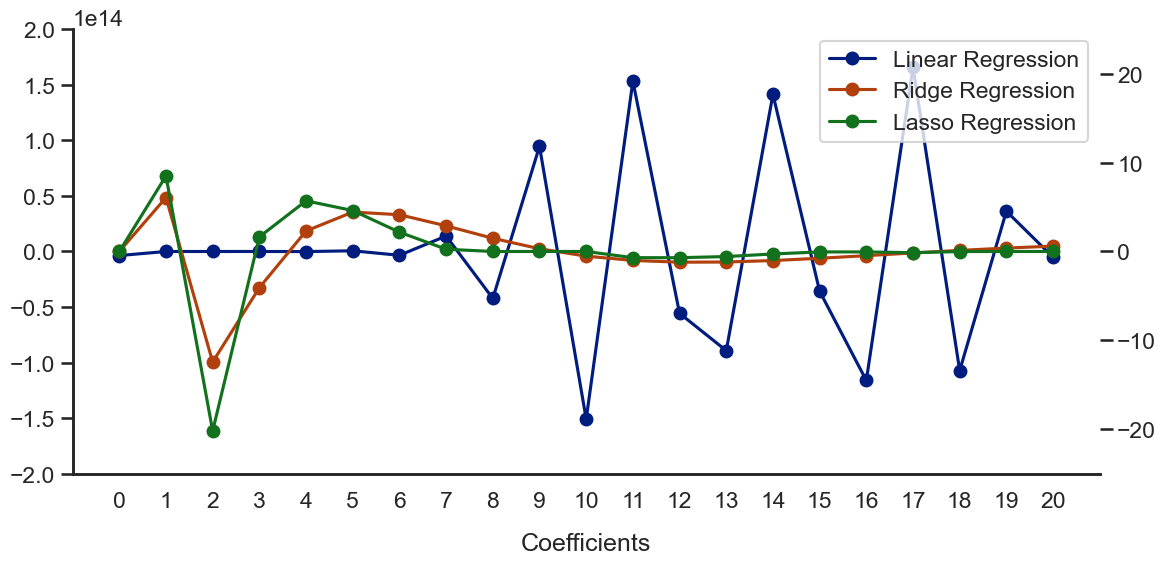

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Colores de la paleta de seaborn
colors = sns.color_palette()

# Configurar figura más grande
fig, ax1 = plt.subplots(figsize=(12, 6))  # Tamaño aumentado
ax2 = ax1.twinx()

# Graficar los coeficientes de la regresión lineal
ax1.plot(lr.coef_.ravel(), 
         marker='o', color=colors[0], label='Linear Regression')

# Graficar los coeficientes de regresión regularizada
ax2.plot(rr.coef_.ravel(), 
         marker='o', color=colors[1], label='Ridge Regression')
ax2.plot(lassor.coef_.ravel(), 
         marker='o', color=colors[2], label='Lasso Regression')

# Ajustar los límites de los ejes y
ax1.set_ylim(-2e14, 2e14)
ax2.set_ylim(-25, 25)

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Configurar etiquetas al lado de la gráfica
ax1.set_xlabel('Coefficients', labelpad=15)

# Configurar ticks en x
ax1.set_xticks(range(len(lr.coef_)))

# Mejorar apariencia de la gráfica
sns.despine()
plt.tight_layout()
plt.show()


## Pregunta 4

Para las preguntas restantes, trabajaremos con el conjunto de dat  [data set](https://www.kaggle.com/c/house-prices-advanced-regression-techniques?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01)o s de la lección anterior, basado en los precios de la vivienda en Ames, Iowa. Hay una gran cantidad de características; consulte los ejercicios de la semana tres para obtener más información sobre ellas.

Para comenzar:

* Importe los datos con Pandas, elimine los valores nulos y codifique los categóricone-hotliente. Se pueden usar los codificadores de características de Scikit-learn o el método `get_dummies` de Pandas.
* Dividir los datos en conjuntos de entrenamiento y prueba.
* Transformar logaritmos para las características sesgadas.
* Se puede intentar el escalado, aunque puede ser interesante ver qué tan bien funciona la regularización sin escalar las características.

In [70]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/Ames_Housing_Sales.csv")
data.head(5)

,1stFlrSF,2ndFlrSF,3SsnPorch,Alley,BedroomAbvGr,BldgType,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,...,ScreenPorch,Street,TotRmsAbvGrd,TotalBsmtSF,Utilities,WoodDeckSF,YearBuilt,YearRemodAdd,YrSold,SalePrice
0,856.0,854.0,0.0,NaN,3,1Fam,TA,No,706.0,0.0,...,0.0,Pave,8,856.0,AllPub,0.0,2003,2003,2008,208500.0
1,1262.0,0.0,0.0,NaN,3,1Fam,TA,Gd,978.0,0.0,...,0.0,Pave,6,1262.0,AllPub,298.0,1976,1976,2007,181500.0
2,920.0,866.0,0.0,NaN,3,1Fam,TA,Mn,486.0,0.0,...,0.0,Pave,6,920.0,AllPub,0.0,2001,2002,2008,223500.0
3,961.0,756.0,0.0,NaN,3,1Fam,Gd,No,216.0,0.0,...,0.0,Pave,7,756.0,AllPub,0.0,1915,1970,2006,140000.0
4,1145.0,1053.0,0.0,NaN,4,1Fam,TA,Av,655.0,0.0,...,0.0,Pave,9,1145.0,AllPub,192.0,2000,2000,2008,250000.0


Crea una lista de datos categóricos y realiza una codificación one-hot. El codificador one-hot de Pandas (`get_dummies`) funciona bien con datos definidos como categóricos.

In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   1stFlrSF       1379 non-null   float64
 1   2ndFlrSF       1379 non-null   float64
 2   3SsnPorch      1379 non-null   float64
 3   Alley          82 non-null     object 
 4   BedroomAbvGr   1379 non-null   int64  
 5   BldgType       1379 non-null   object 
 6   BsmtCond       953 non-null    object 
 7   BsmtExposure   953 non-null    object 
 8   BsmtFinSF1     1379 non-null   float64
 9   BsmtFinSF2     1379 non-null   float64
 10  BsmtFinType1   953 non-null    object 
 11  BsmtFinType2   952 non-null    object 
 12  BsmtFullBath   1379 non-null   int64  
 13  BsmtHalfBath   1379 non-null   int64  
 14  BsmtQual       953 non-null    object 
 15  BsmtUnfSF      1379 non-null   float64
 16  CentralAir     1379 non-null   object 
 17  Condition1     1379 non-null   object 
 18  Conditio

Observamos el tamaño del dataframe

In [74]:
data.shape

(1379, 80)

Observamos que el dataframe, tenemos $1379$ filas con $80$ columnas

### Variables categoricas codificación

In [76]:
# Convertir las variables categóricas en variables dummy (0 o 1)
# drop_first=True elimina la primera categoría de cada variable para evitar multicolinealidad
data = pd.get_dummies(data, drop_first=True)
# Mostrar los nombres de las columnas del DataFrame después de la transformación
data.columns

Index(['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BedroomAbvGr', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF',
       'EnclosedPorch',
       ...
       'SaleType_CWD', 'SaleType_Con', 'SaleType_ConLD', 'SaleType_ConLI',
       'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth', 'SaleType_WD',
       'Street_Pave', 'Utilities_NoSeWa'],
      dtype='object', length=241)

In [78]:
data.shape

(1379, 241)

A continuación, divida los datos en conjuntos de datos de entrenamiento y de prueba.

In [80]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, random_state=42)

### Variables numéricas estandarización.

Hay varias columnas con características sesgadas, a las que se les puede aplicar una transformación logarítmica. Tenga en cuenta que esto incluye el predictor `SalePrice`. Sin embargo, lo dejaremos como está.


In [82]:
# Crear una lista de columnas de tipo float para verificar si están sesgadas
mask = data.dtypes == float  # Genera una serie booleana donde True indica que la columna es de tipo float
float_cols = data.columns[mask]  # Selecciona los nombres de las columnas que son de tipo float
float_cols

Index(['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'EnclosedPorch', 'GarageArea', 'GarageYrBlt', 'GrLivArea',
       'LotArea', 'LotFrontage', 'LowQualFinSF', 'MasVnrArea', 'MiscVal',
       'OpenPorchSF', 'PoolArea', 'ScreenPorch', 'TotalBsmtSF', 'WoodDeckSF',
       'SalePrice'],
      dtype='object')

#### Escalamiento logarítmico

In [84]:
# Definir el límite de sesgo (skew) a considerar como significativo
skew_limit = 0.75

# Calcular el sesgo de las columnas numéricas (float) del conjunto de entrenamiento
skew_vals = train[float_cols].skew()

# Seleccionar las columnas cuyo sesgo absoluto supera el límite definido
skew_cols = (
    skew_vals
    .sort_values(ascending=False)        # Ordenar los valores de sesgo de mayor a menor
    .to_frame()                          # Convertir la Serie a DataFrame
    .rename(columns={0: 'Skew'})        # Renombrar la columna a 'Skew' para mayor claridad
    .query('abs(Skew) > {0}'.format(skew_limit))  # Filtrar solo las columnas con sesgo > 0.75
)

# Mostrar las columnas que tienen un sesgo significativo
skew_cols


,Skew
MiscVal,26.915364
PoolArea,15.777668
LotArea,11.501694
LowQualFinSF,11.210638
3SsnPorch,10.150612
ScreenPorch,4.599803
BsmtFinSF2,4.466378
EnclosedPorch,3.218303
LotFrontage,3.138032
MasVnrArea,2.492814


Transforma todas las columnas donde la desviación sea mayor a $0,75$, excluyendo "SalePrice".

In [86]:
def plot_log1p_histograms(df, columns):
    """
    Grafica histogramas de columnas específicas de un DataFrame antes y después de aplicar np.log1p.

    Args:
        df (pd.DataFrame): DataFrame con los datos.
        columns (list): Lista de columnas a graficar.
    """
    for field in columns:
        if field not in df.columns:
            print(f"Column '{field}' not found in DataFrame. Skipping.")
            continue
        
        if not np.issubdtype(df[field].dtype, np.number):
            print(f"Skipping column '{field}' because it is not numeric.")
            continue
        
        fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(12, 5))
        
        df[field].hist(ax=ax_before, bins=30)
        df[field].apply(np.log1p).hist(ax=ax_after, bins=30)
        
        ax_before.set(title=f'{field} - before np.log1p', ylabel='frequency', xlabel='value')
        ax_after.set(title=f'{field} - after np.log1p', ylabel='frequency', xlabel='value')
        
        fig.suptitle(f'Field "{field}"', fontsize=14)
        plt.tight_layout()
        plt.show()


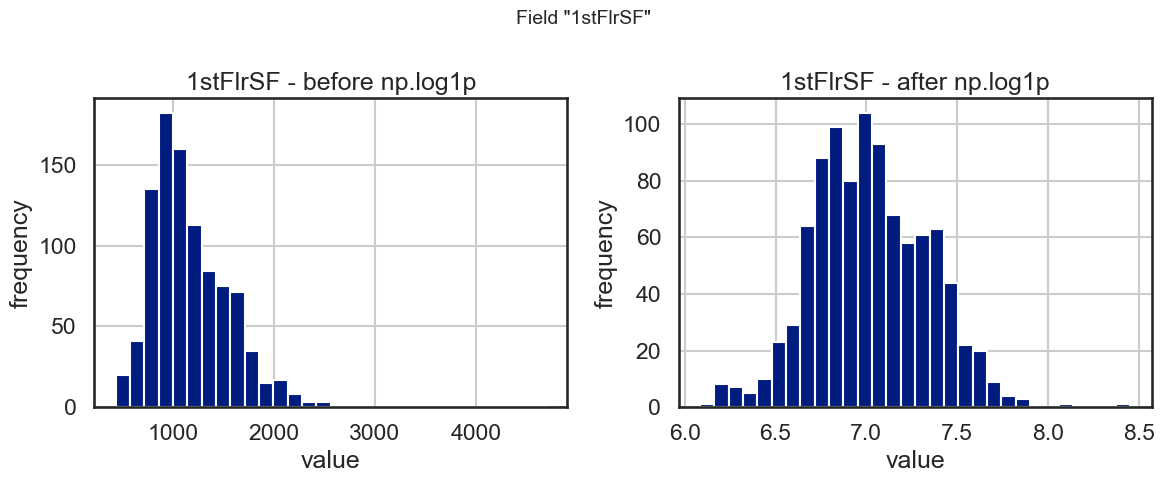

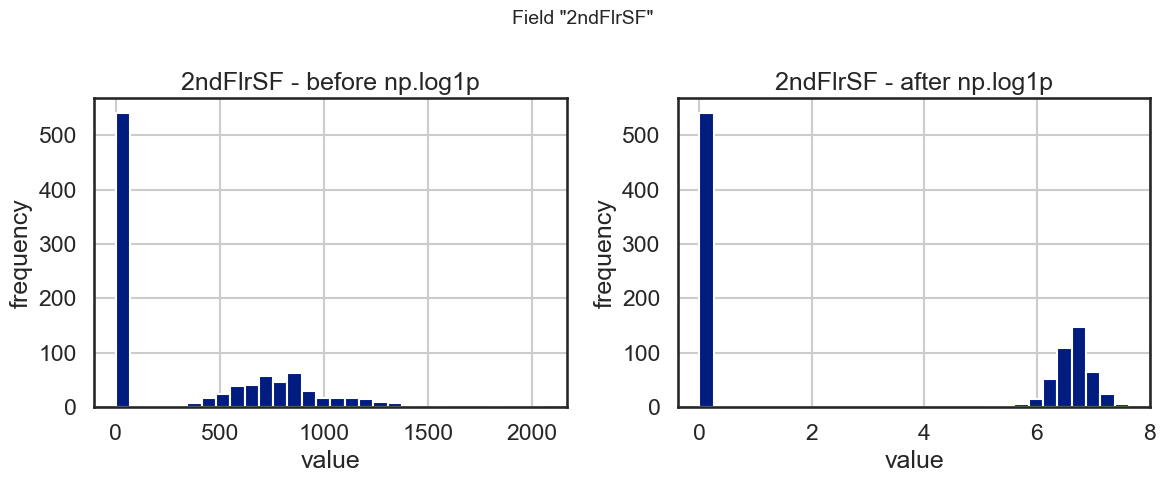

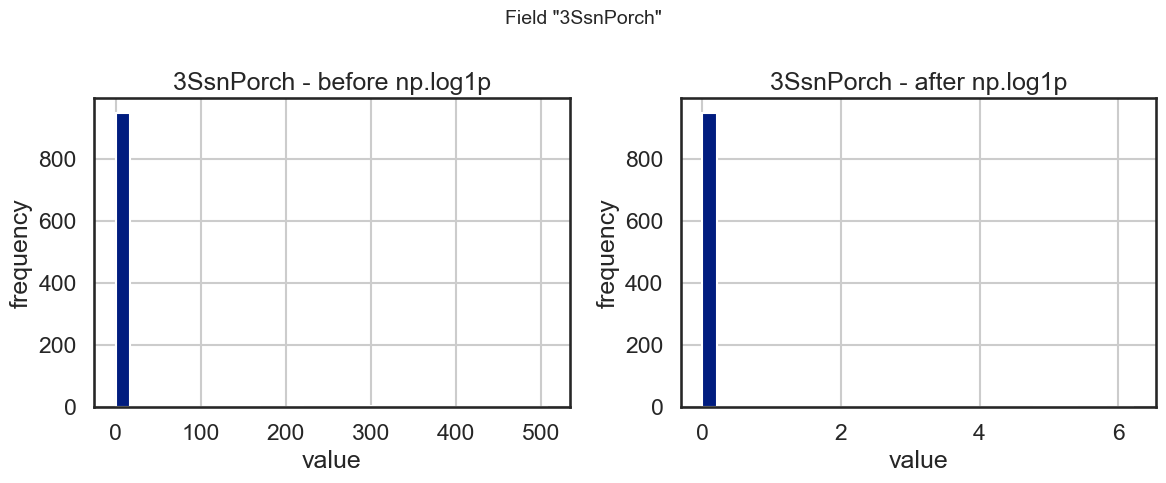

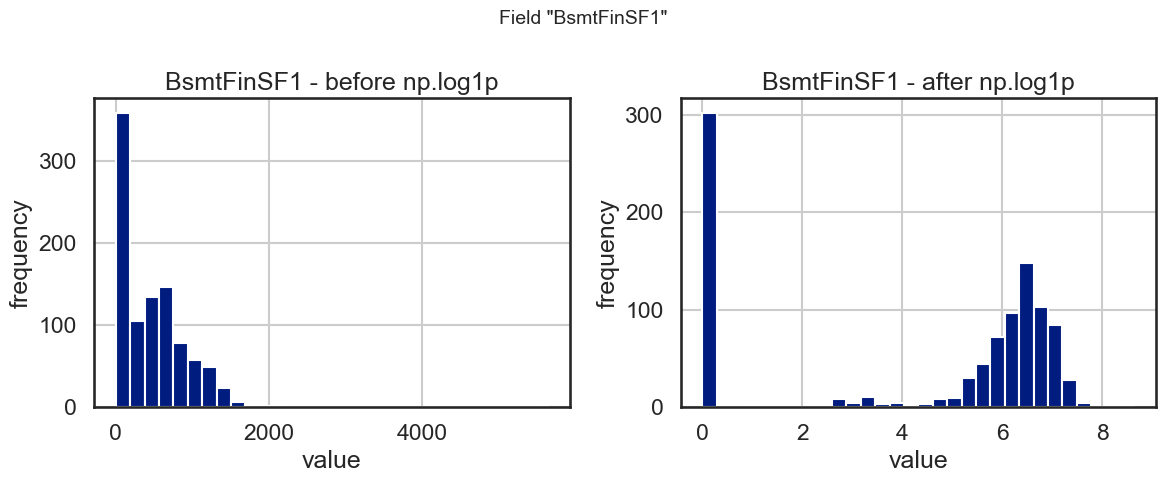

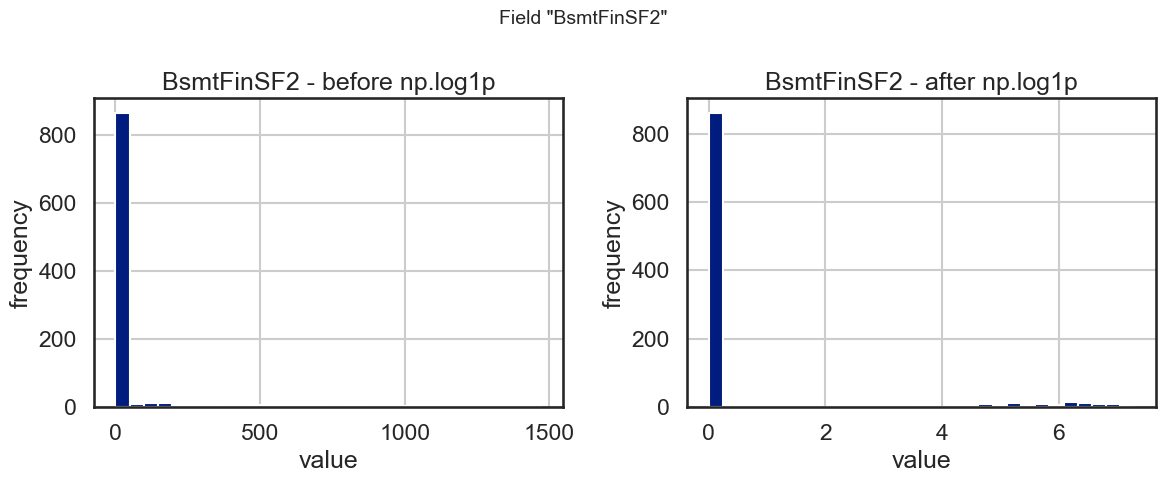

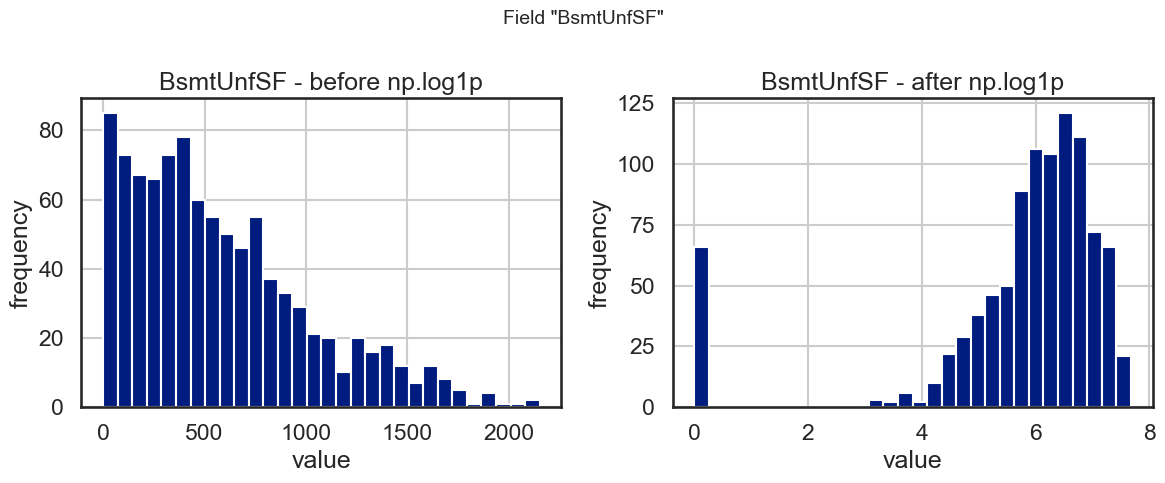

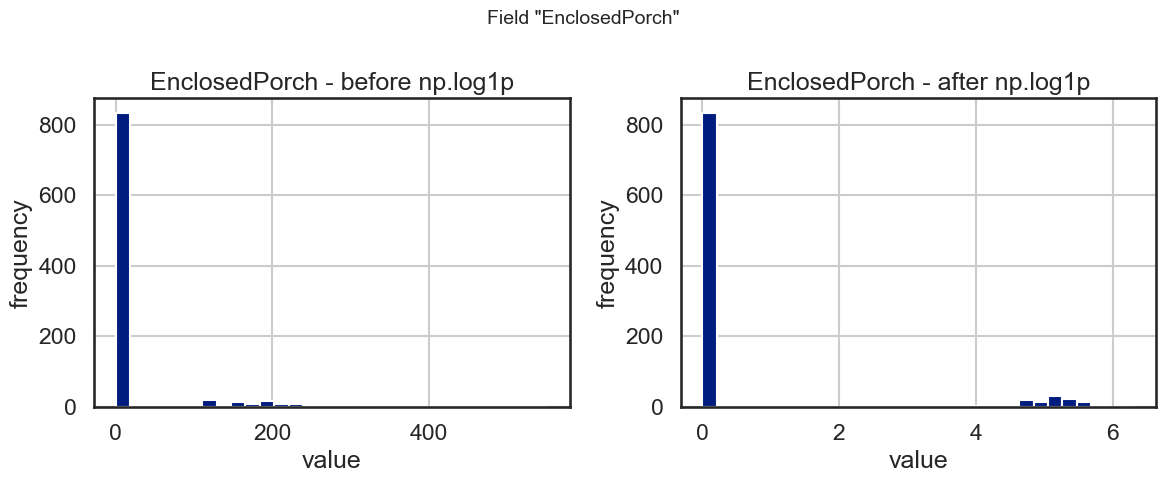

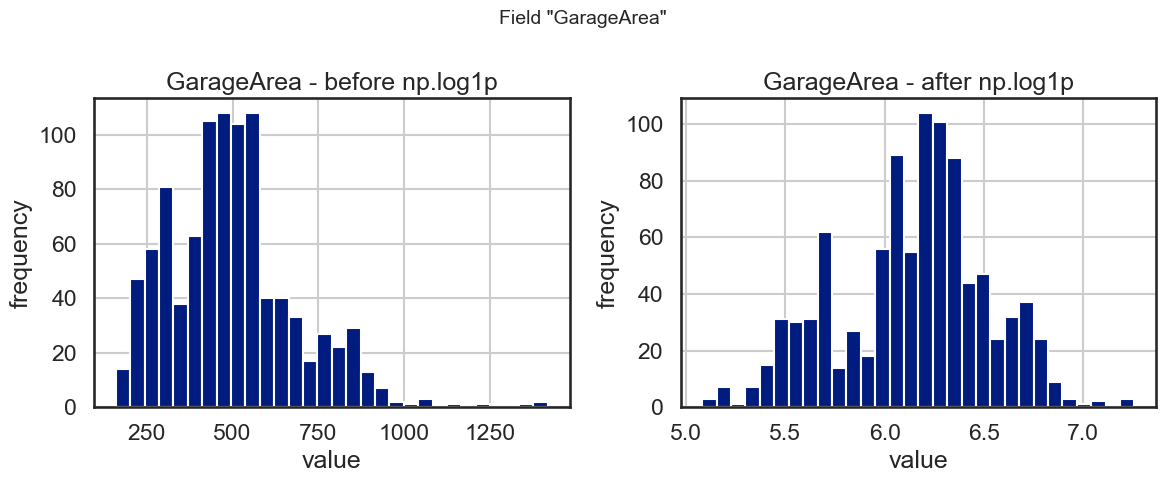

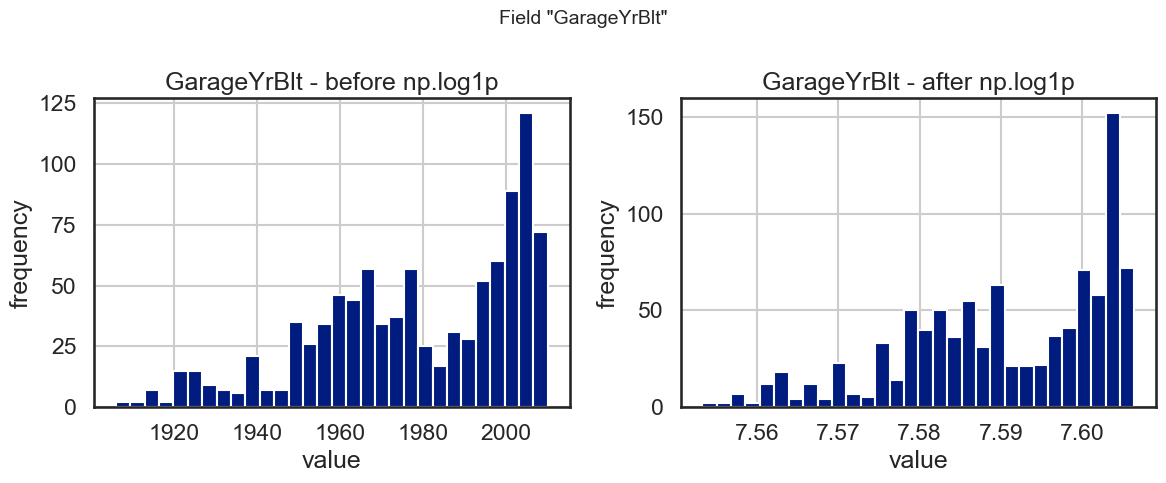

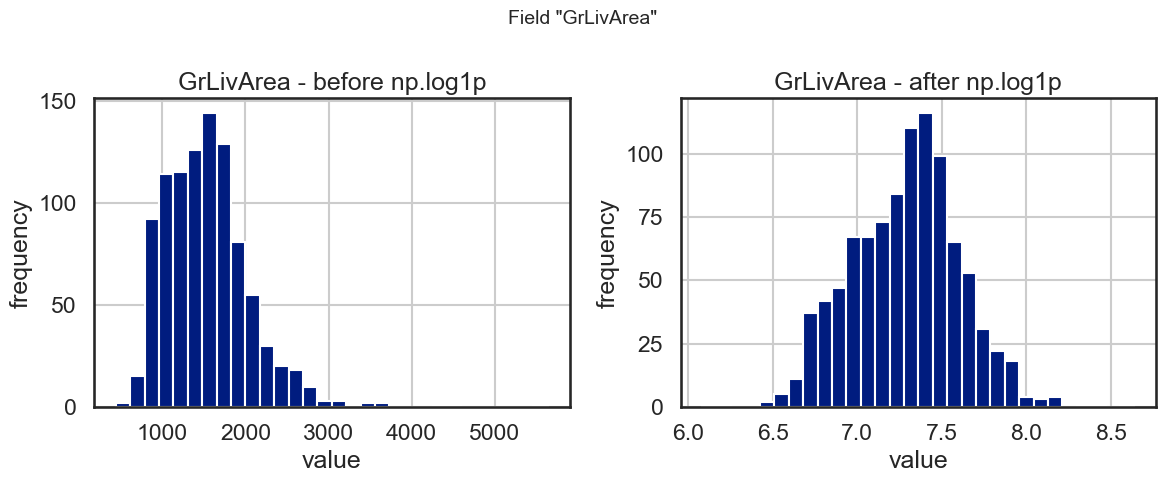

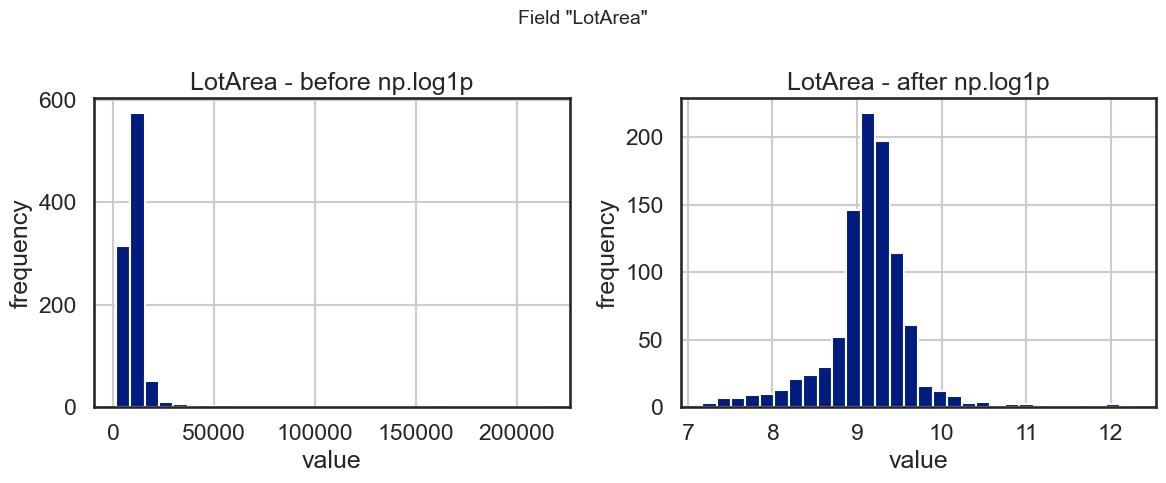

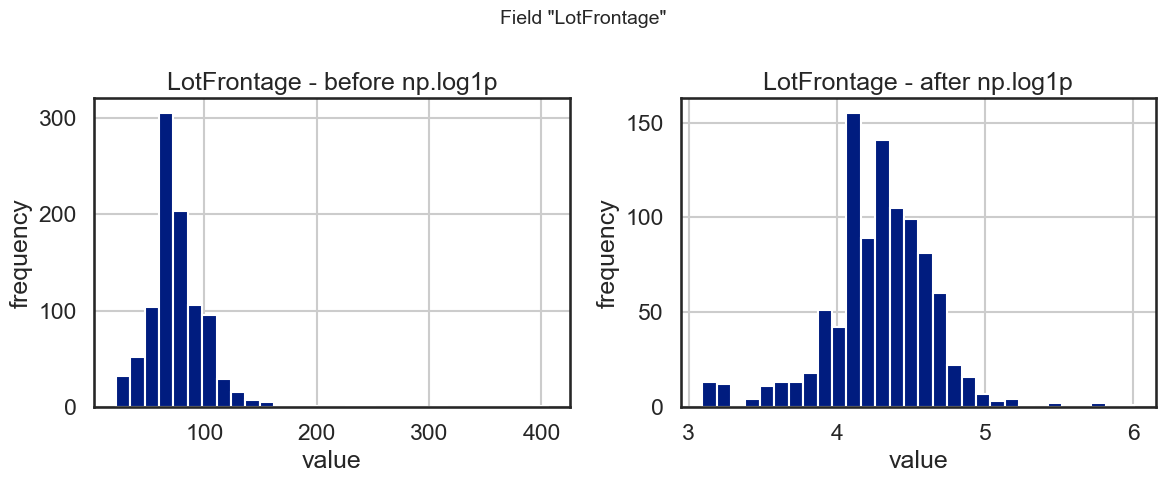

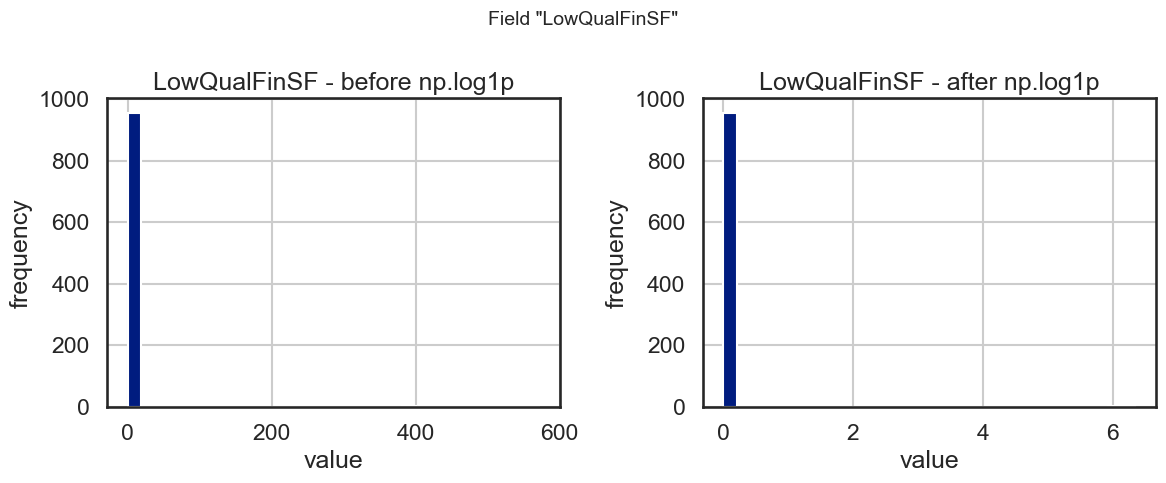

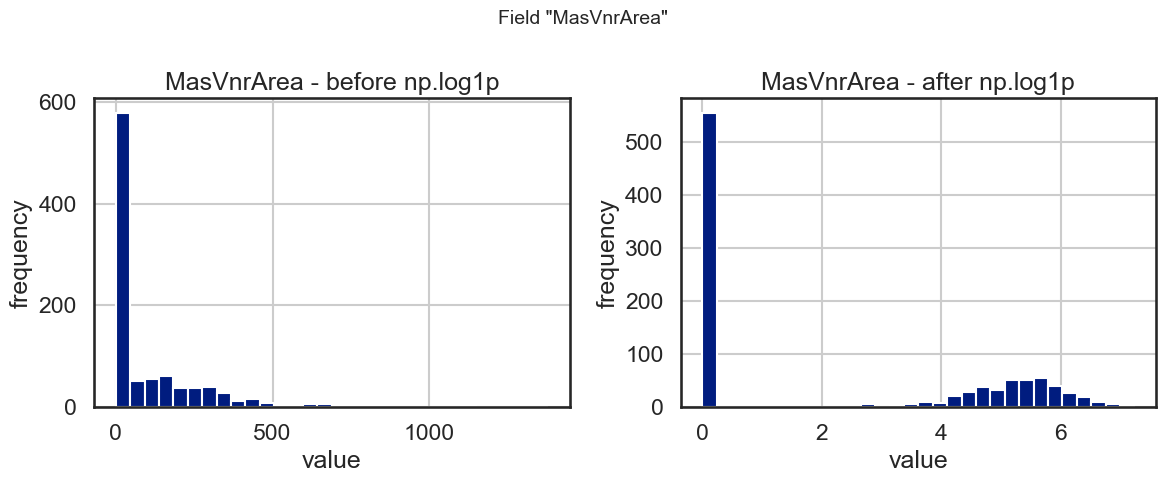

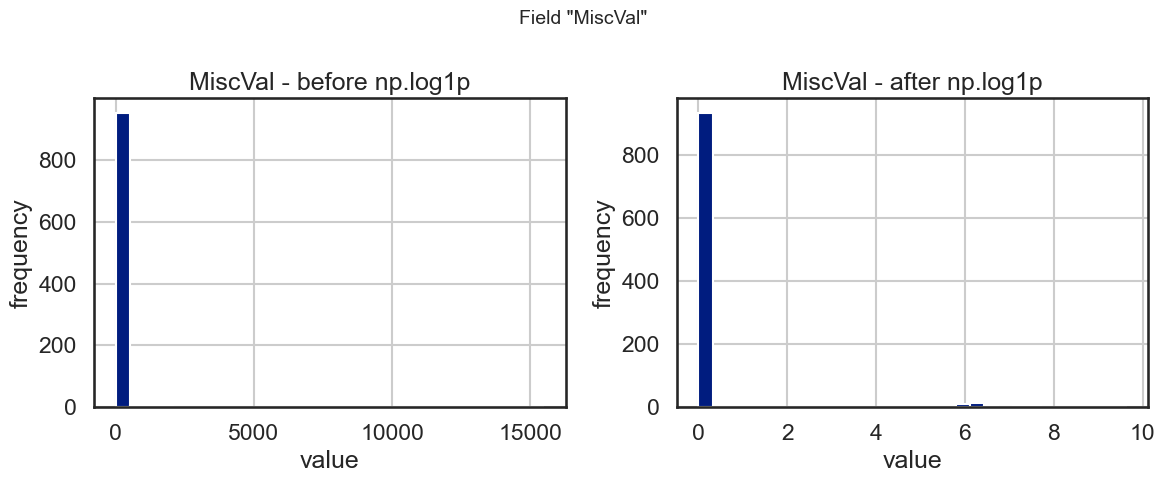

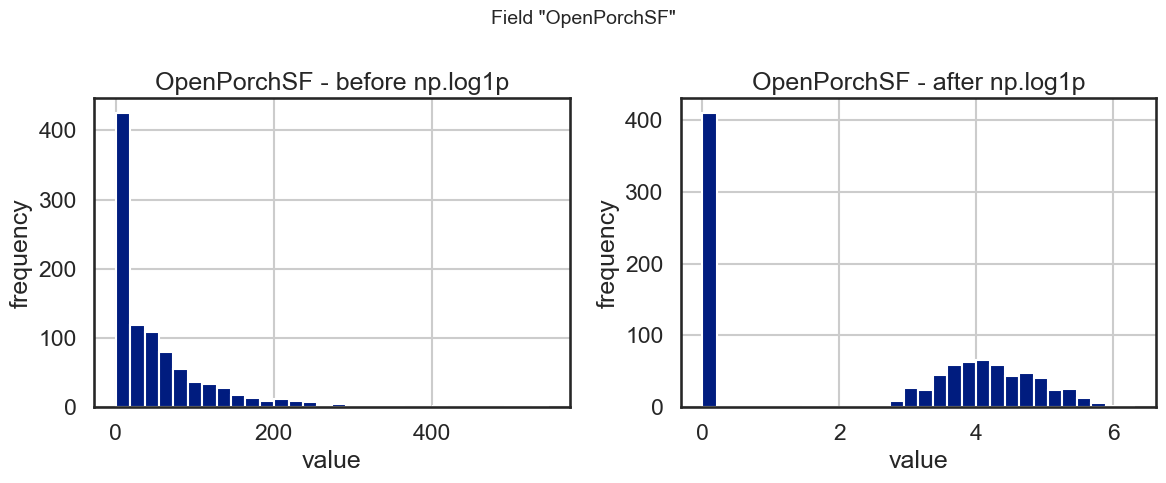

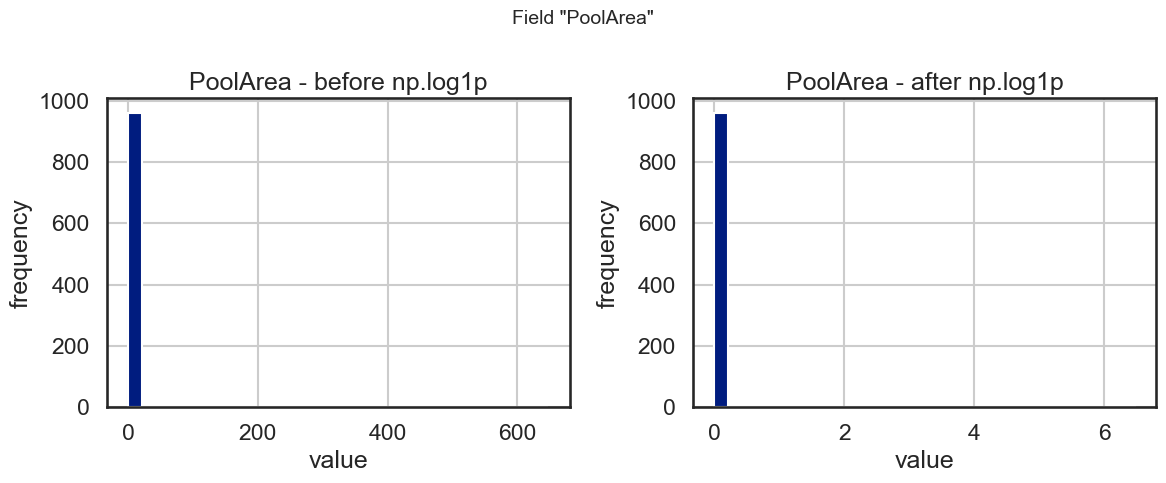

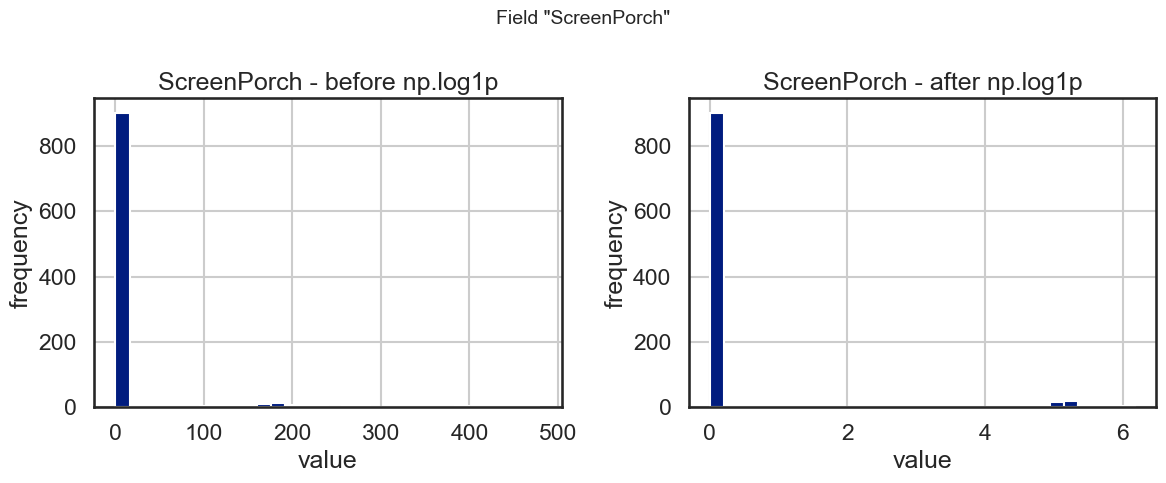

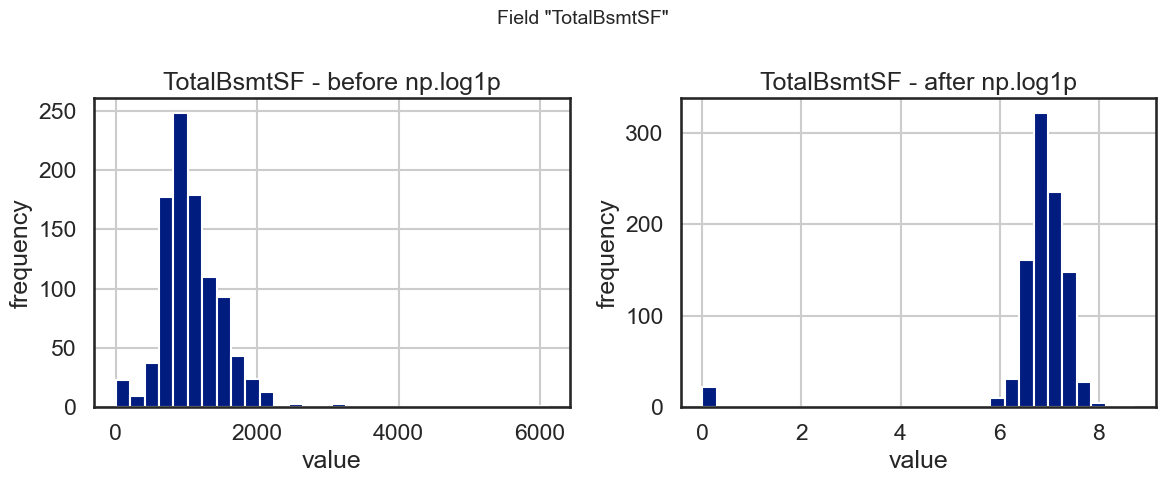

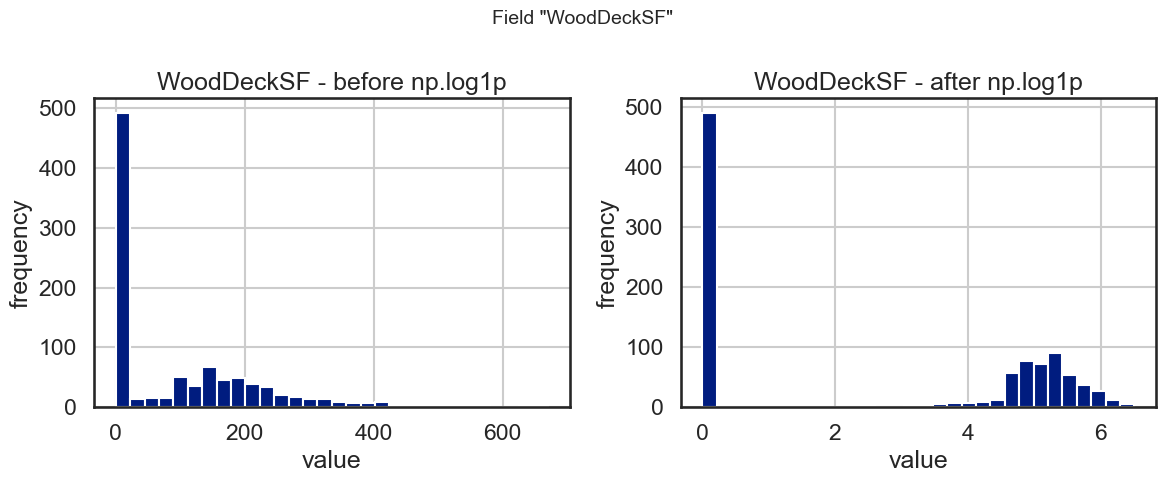

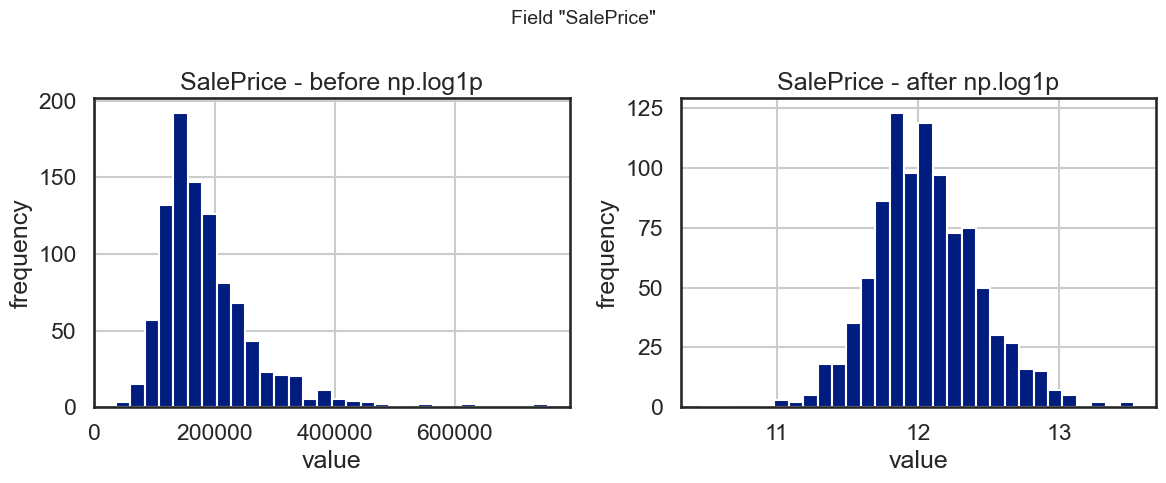

In [88]:
plot_log1p_histograms(train, float_cols)

Antes de escalar los valores con el logaritmo, observa que datos se tienen:

In [93]:
test.head(5)

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,EnclosedPorch,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Pave,Utilities_NoSeWa
599,1518.0,0.0,0.0,1,1218.0,0.0,0,0,300.0,0.0,...,False,False,False,False,False,False,False,True,True,False
881,925.0,0.0,0.0,2,338.0,466.0,0,1,121.0,0.0,...,False,False,False,False,False,False,False,True,True,False
634,1095.0,679.0,0.0,4,0.0,0.0,1,0,1095.0,90.0,...,False,False,False,False,False,False,False,True,True,False
425,888.0,868.0,0.0,3,742.0,0.0,1,0,130.0,0.0,...,False,False,False,False,False,False,False,True,True,False
906,1337.0,0.0,0.0,3,699.0,0.0,1,0,638.0,0.0,...,False,False,False,False,False,False,False,True,True,False


In [95]:
# Desactiva las advertencias de pandas sobre "chained assignment"
# Esto ocurre cuando modificas un DataFrame de forma que pandas no está seguro si estás trabajando sobre una copia o el original
pd.options.mode.chained_assignment = None

# Recorre todas las columnas que tienen skew (distribución sesgada) alta
# skew_cols.index.tolist() devuelve la lista de nombres de columnas
for col in skew_cols.index.tolist():
    
    # Saltamos la columna "SalePrice" porque probablemente es la variable objetivo y no queremos transformarla
    if col == "SalePrice":
        continue
    
    # Aplicamos la transformación logarítmica np.log1p (log(1 + x)) a la columna en el DataFrame de entrenamiento
    # Esto ayuda a reducir la skewness y acercar la distribución a una normal
    train[col] = np.log1p(train[col])
    
    # Hacemos lo mismo en el DataFrame de test
    # Aquí se usa .apply(np.log1p) para aplicar la función elemento a elemento
    test[col] = test[col].apply(np.log1p)  # same thing


In [97]:
test.head(5)

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,EnclosedPorch,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Pave,Utilities_NoSeWa
599,7.325808,0.000000,0.0,1,7.105786,0.000000,0,0,5.707110,0.00000,...,False,False,False,False,False,False,False,True,True,False
881,6.830874,0.000000,0.0,2,5.826000,6.146329,0,1,4.804021,0.00000,...,False,False,False,False,False,False,False,True,True,False
634,6.999422,6.522093,0.0,4,0.000000,0.000000,1,0,6.999422,4.51086,...,False,False,False,False,False,False,False,True,True,False
425,6.790097,6.767343,0.0,3,6.610696,0.000000,1,0,4.875197,0.00000,...,False,False,False,False,False,False,False,True,True,False
906,7.198931,0.000000,0.0,3,6.551080,0.000000,1,0,6.459904,0.00000,...,False,False,False,False,False,False,False,True,True,False


Le aplicamos log, al primer valor de la columna **1stFIrSF**

In [99]:
print(np.log1p(1518.0)) #Observamos el primer valor d

7.325807502595773


Separate features from predictor.


In [104]:
feature_cols = [x for x in train.columns if x != 'SalePrice']
X_train = train[feature_cols]
y_train = train['SalePrice']

X_test  = test[feature_cols]
y_test  = test['SalePrice']

## Pregunta 5

* Escriba una función **`rmse`** que tome valores de verdad y predicción y devuelva el error cuadrático medio. Utilice `mean_squared_error` de sklearn.


\begin{align}
\text{MSE} &= \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \\
\text{RMSE} &= \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} 
\end{align}

In [118]:
# Importamos la función mean_squared_error de scikit-learn
# Esta función calcula el error cuadrático medio entre los valores reales y los predichos
from sklearn.metrics import mean_squared_error

# Definimos una función para calcular el RMSE (Root Mean Squared Error)
def rmse(ytrue, ypredicted):
    # Calcula el MSE usando mean_squared_error
    # Luego le aplicamos la raíz cuadrada para obtener el RMSE
    # RMSE nos da una medida de error en las mismas unidades que la variable objetivo
    return np.sqrt(mean_squared_error(ytrue, ypredicted))


* Ajustar un modelo de regresión lineal básico
* Imprimir el error cuadrático medio para este modelo
* Graficar el precio de venta previsto frente al real según el modelo.

### Modelo de regresión lineal

In [131]:
# Importamos la clase LinearRegression desde scikit-learn
from sklearn.linear_model import LinearRegression

# Creamos un objeto de regresión lineal y lo entrenamos (fit) usando los datos de entrenamiento X_train y y_train
linearRegression = LinearRegression().fit(X_train, y_train)

linearRegression

LinearRegression()

In [133]:
# Calculamos el RMSE (Root Mean Squared Error) usando los valores reales de prueba y_test 
# y las predicciones del modelo sobre X_test
linearRegression_rmse = rmse(y_test, linearRegression.predict(X_test))

# Imprimimos el valor del RMSE obtenido
print(linearRegression_rmse)

42033.4921527996


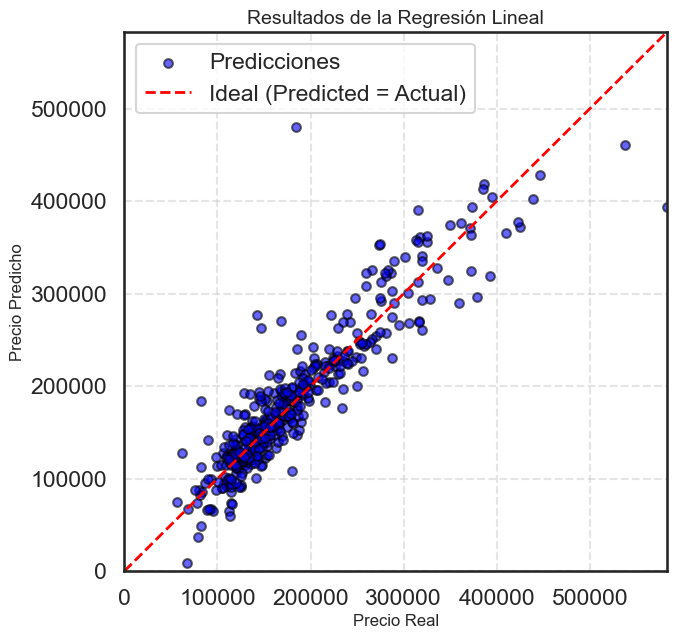

In [137]:
import matplotlib.pyplot as plt
import numpy as np

# Crear figura y eje
plt.figure(figsize=(7,7))
ax = plt.gca()

# Scatter plot de valores reales vs predichos
ax.scatter(y_test, linearRegression.predict(X_test), 
           color='blue', alpha=0.6, edgecolor='k', s=40, label='Predicciones')

# Línea de referencia donde Predicted = Actual
lims = [0, max(y_test.max(), linearRegression.predict(X_test).max())]
ax.plot(lims, lims, 'r--', lw=2, label='Ideal (Predicted = Actual)')

# Etiquetas y título
ax.set_xlabel('Precio Real', fontsize=12)
ax.set_ylabel('Precio Predicho', fontsize=12)
ax.set_title('Resultados de la Regresión Lineal', fontsize=14)

# Límites de los ejes
ax.set_xlim(lims)
ax.set_ylim(lims)

# Leyenda y cuadrícula
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# Mostrar gráfico
plt.show()


## Pregunta 6

La regresión de Ridge utiliza la normalización L2 para reducir la magnitud de los coeficientes. Esto puede ser útil en situaciones con alta varianza. Las funciones de regularización de Scikit-learn contienen versiones con validación cruzada integrada.

* Ajuste un modelo de Ridge regular (sin validación cruzada) a un rango de valores de $\alpha$ y grafique el RMSE utilizando la función de error con validación cruzada que creó anteriormente.
* Utilice $$[0.005, 0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 80]$$ como rango de valores de alfa.
* Luego, repita el ajuste de los modelos de Ridge utilizando el rango de valores de $\alpha$ de la sección anterior. Compare los resultados.


Ahora, para el método <code>RidgeCV </code>. Lamentablemente, no es posible obtener los valores alfa de los modelos no seleccionados. Los valores de error y alfa resultantes son muy similares a los obtenidos anteriormente.


### RidgeCV

RidgeCV es una versión de regresión **Ridge** que selecciona automáticamente el mejor valor de alpha mediante validación cruzada.

In [149]:
from sklearn.linear_model import RidgeCV

$\alpha $ controla la penalización L2: 
* Valores pequeños ≈ poca regularización.
* Valores grandes ≈ mayor regularización.

In [155]:
alphas = [0.005, 0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 80]

Creamos un modelo **RidgeCV** usando los valores de $\alpha $ definidos y $4$ **k-folds cross-validation**. Lugeo, lo ajusta a los datos de entrenamiento (X_train, y_train)

In [158]:
ridgeCV = RidgeCV(alphas=alphas, 
                  cv=4).fit(X_train, y_train)
ridgeCV

RidgeCV(alphas=[0.005, 0.05, 0.1, 0.3, 1, 3, 5, 10, 15, 30, 80], cv=4)

Calculamos el **RMSE** sobre los datos de prueba.

In [161]:
ridgeCV_rmse = rmse(y_test, ridgeCV.predict(X_test))

Imprimimos el $\alpha $ que minimiza el error y el **RMSE** en el conjunto de prueba.

In [176]:
print(f"alpha (minimiza error) = {ridgeCV.alpha_}    \nRMSE (prueba) = {ridgeCV_rmse}")


alpha (minimiza error) = 10.0    
RMSE (prueba) = 32022.031469901223


## Pregunta 7

Al igual que la función `RidgeCV`, también existe la función `LassoCV` que utiliza una función de regularización L1 y validación cruzada. La regularización L1 reduce selectivamente algunos coeficientes, eliminando eficazmente las características.

La función `LassoCV` no permite configurar la función de puntuación. Sin embargo, la función de error personalizada (`rmse`) creada anteriormente puede utilizarse para evaluar el error en el modelo final.

De igual forma, existe una función de red elástica con validación cruzada, `ElasticNetCV`, que combina las regularizaciones L2 y L1.

* Ajuste un modelo Lasso mediante validación cruzada y determine el valor óptimo de $\alpha$ y el RMSE utilizando la función creada anteriormente. Tenga en cuenta que la magnitud de $\alpha$ puede ser diferente a la del modelo Ridge.
* Repita este proceso con el modelo de red elástica.
* Compare los resultados mediante una tabla o un gráfico.

Utilice lasalphasetes letras:\
`[1e-5, 5e-5, 0.0001, 0.0005]`

### LassoCV
LassoCV es una versión de regresión lasso que selecciona automáticamente el mejor valor de $\alpha $ mediante validación cruzada.

In [ ]:
from sklearn.linear_model import LassoCV

Define un arreglo de posibles valores de $\alpha $ para regularización $L_1$.
$\alpha $ controla la penalización $L_1$:

* Valores pequeños ≈ poca regularización.
* Valores grandes ≈ mayor regularización.

In [192]:
alphas2 = np.array([1e-5, 5e-5, 0.0001, 0.0005])


Crea un modelo **LassoCV** usando los valores de $\alpha $ definidos. Con un máximo de iteracciones de $50,000$ (max_iter) para asegurar convergencia.
y $3$ **k-fold cross-validation**. Luego se ajusta a los datos de entrenamiento.

In [195]:
lassoCV = LassoCV(alphas=alphas2,
                  max_iter=int(5e4),
                  cv=3).fit(X_train, y_train)
lassoCV

LassoCV(alphas=array([0.00001, 0.00005, 0.0001 , 0.0005 ]), cv=3,
        max_iter=50000)

Calculamos el **RMSE** sobre los datos de prueba, usando la predicción del modelo entrenado.

In [199]:
lassoCV_rmse = rmse(y_test, lassoCV.predict(X_test))

Imprime el valor de $\alpha $ que minimiza el error y el **RMSE** en el conjunto de prueba.

**Nota:** Lasso suele ser más lento que **Ridge** porque la penalización $L_1$ puede llevar a soluciones donde muchos coeficientes se vuelven exactamente $0$, lo que requiere algoritmos iterativos más complejos.

In [201]:
print(lassoCV.alpha_, lassoCV_rmse)  # Lasso is slower

0.0005 46069.63857009737


Podemos determinar cuántas de estas características siguen siendo distintas de cero.

In [206]:
print('De {} coeficientes, {} son distintos de cero con Lasso.'.format(len(lassoCV.coef_), 
                                                               len(lassoCV.coef_.nonzero()[0])))

De 240 coeficientes, 230 son distintos de cero con Lasso.


### ElasticNetCV

Ahora pruebe la red elástica, con los mismos alfas que en Lasso y l1\_ratios entre 0,1 y 0,9.

**ElasticNetCV** permite entrenar un modelo Elastic Net y optimizar automáticamente los hiperparámetros $\alpha $ y l1_ratios mediante validación cruzada.

In [215]:
from sklearn.linear_model import ElasticNetCV

Se define un rango de valores para l1_ratios, que controla la mezcla entre Lasso($L_1$) y Ridge($L_2$).
Se generan $9$ valores equidistantes entre $0.1$ y $0.9$

In [223]:
l1_ratios = np.linspace(0.1, 0.9, 9)

In [225]:
l1_ratios 

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

Creamos un objeto **ElasticNetCV** con:
* $\alpha =  [1e-5, 5e-5, 0.0001, 0.0005]  $  (lista de posibles valores)
* l1_ratios: lista de posibles combinaciones L1/L2
* max_iter=int(1e4): número máximo de iteraciones para la optimización

Luego, entrena el modelo usando los datos de entrenamiento (X_train, y_train)

In [240]:
elasticNetCV = ElasticNetCV(alphas=alphas2, 
                            l1_ratio=l1_ratios,
                            max_iter=int(1e4)).fit(X_train, y_train)
elasticNetCV

ElasticNetCV(alphas=array([0.00001, 0.00005, 0.0001 , 0.0005 ]),
             l1_ratio=array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
             max_iter=10000)

Calculamos el **RMSE** sobre los datos de prueba, usando la predicción del modelo entrenado (**ElasticNetCV**)

In [247]:
elasticNetCV_rmse = rmse(y_test, elasticNetCV.predict(X_test))

A continuación, obtenemos lo siguiente:
* $\alpha $ óptimo encontrado por **ElasticNetCV**
* l1_ratio_ óptimo encontrado
* **RMSE** en los datos de prueba

In [248]:
print(elasticNetCV.alpha_, elasticNetCV.l1_ratio_, elasticNetCV_rmse)

0.0005 0.1 36040.65858463386


La forma más fácil de comparar el cálculo de RMSE de todos los modelos es en una tabla.

### RMSE modelos Linear vs Ridge vs Lasso vs ElasticNet

Creamos una lista con los valores de RMSE (Root Mean Squared Error) obtenidos  de diferentes modelos de regresión: 
* regresión lineal.
* Ridge.
* Lasso.
* ElasticNet.

In [249]:
rmse_vals = [linearRegression_rmse, ridgeCV_rmse, lassoCV_rmse, elasticNetCV_rmse]

Definimos las etiquetas correspondientes a cada modelo, que luego usaremos como índice en un DataFrame.

In [250]:
labels = ['Linear', 'Ridge', 'Lasso', 'ElasticNet']

Convertimos la lista de **RMSE** en un objeto pandas Series, usando las etiquetas como índice.
Luego lo transformamos en un DataFrame para tenerlo en formato tabular.

In [251]:
rmse_df = pd.Series(rmse_vals, index=labels).to_frame()

 Renombramos la columna que por defecto se llama 0 a 'RMSE' para que sea más claro. Mostramos el dataframe

In [253]:
rmse_df.rename(columns={0: 'RMSE'}, inplace=True)
rmse_df

,RMSE
Linear,42033.492153
Ridge,32022.031470
Lasso,46069.638570
ElasticNet,36040.658585


También podemos hacer un gráfico de los precios de vivienda reales frente a los previstos como antes.

#### Gráfico

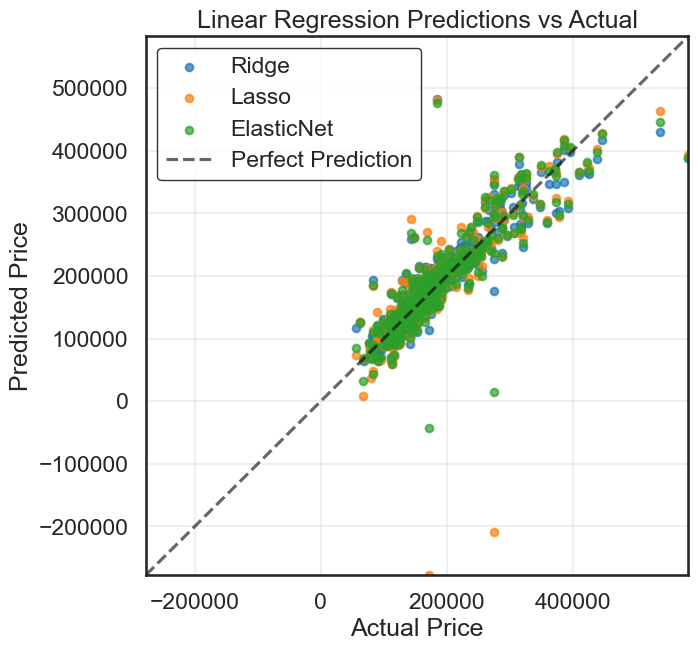

In [266]:
import matplotlib.pyplot as plt
import numpy as np

# Crear figura y ejes
plt.figure(figsize=(7,7))
ax = plt.gca()

labels = ['Ridge', 'Lasso', 'ElasticNet']
models = [ridgeCV, lassoCV, elasticNetCV]
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Graficar las predicciones de cada modelo
for mod, lab, col in zip(models, labels, colors):
    ax.scatter(y_test, mod.predict(X_test), 
               label=lab, color=col, s=30, alpha=0.7)

# Línea de referencia perfecta (predicción = valor real)
lims = [min(y_test.min(), min([m.predict(X_test).min() for m in models])),
        max(y_test.max(), max([m.predict(X_test).max() for m in models]))]
ax.plot(lims, lims, 'k--', alpha=0.6, label='Perfect Prediction')

# Configuración de leyenda
leg = ax.legend(frameon=True, loc='upper left')
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.0)

# Etiquetas y título
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title('Linear Regression Predictions vs Actual')

# Ajustar límites iguales para comparar correctamente
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.grid(alpha=0.3)
plt.show()


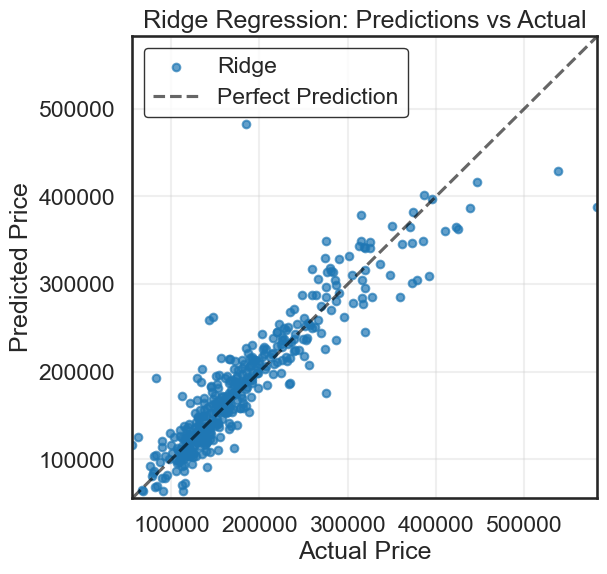

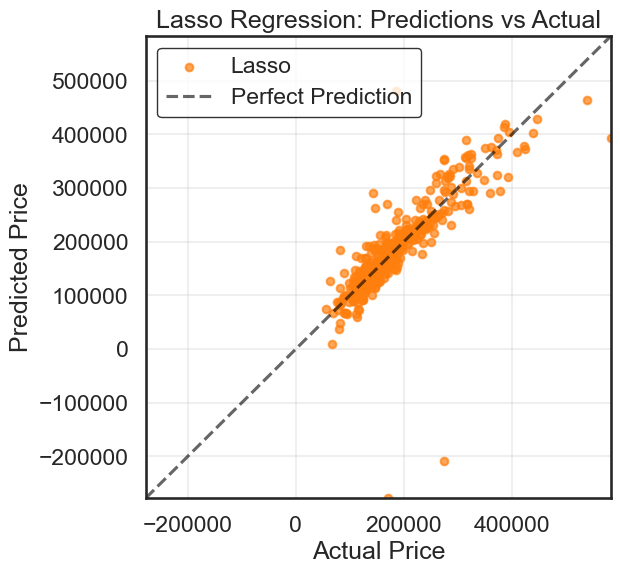

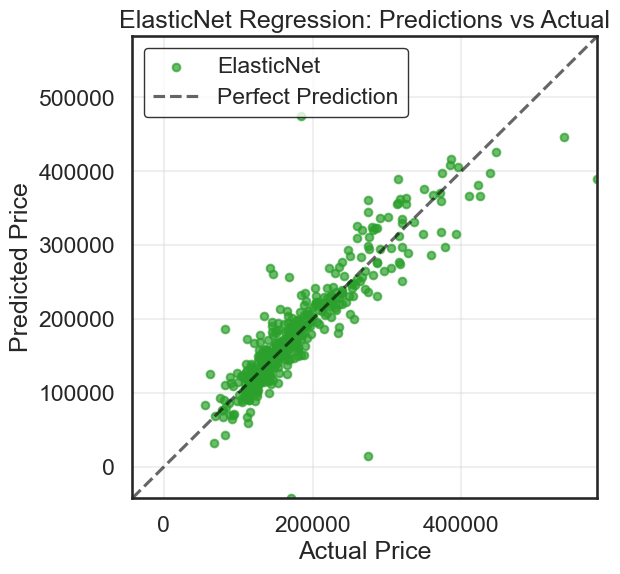

In [268]:
import matplotlib.pyplot as plt
import numpy as np

# Lista de modelos y etiquetas
labels = ['Ridge', 'Lasso', 'ElasticNet']
models = [ridgeCV, lassoCV, elasticNetCV]
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Recorrer cada modelo y graficarlo individualmente
for mod, lab, col in zip(models, labels, colors):
    plt.figure(figsize=(6,6))
    ax = plt.gca()
    
    # Graficar predicciones vs valores reales
    ax.scatter(y_test, mod.predict(X_test), color=col, alpha=0.7, s=30, label=lab)
    
    # Línea de referencia perfecta
    lims = [min(y_test.min(), mod.predict(X_test).min()),
            max(y_test.max(), mod.predict(X_test).max())]
    ax.plot(lims, lims, 'k--', alpha=0.6, label='Perfect Prediction')
    
    # Configuración de leyenda
    leg = ax.legend(frameon=True, loc='upper left')
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.0)
    
    # Etiquetas y título
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'{lab} Regression: Predictions vs Actual')
    
    # Ajustar límites iguales
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    # Rejilla
    plt.grid(alpha=0.3)
    
    # Mostrar gráfico
    plt.show()


## Pregunta 8

Exploremos el descenso de gradiente estocástico en este ejercicio.

Recuerde **que los modelos lineales, en general, son sensibles al escal**ado.
Sin embargo, el SGD es *muy* sensible al escalado.

Además, un valor alto de tasa de aprendizaje puede provocar que el algoritmo diverja, mientras que un valor demasiado bajo puede tardar demasiado en converger.

* Ajuste un modelo de descenso de gradiente estocástico sin penalización de regularización (el parámetro relevante es `penalty`).
* Ahora ajuste los modelos de descenso de gradiente estocástico con cada una de las tres penalizaciones (L2, L1, Red Elástica) utilizando los valores de los parámetros determinados mediante la validación cruzada anterior.
* No escale los datos antes de ajustar el modelo.
* Compare los resultados con los obtenidos sin utilizar el descenso de gradiente estocástico.

### SGDRegressor
SGDRegressor: Descenco de gradiente estocástico.

In [275]:
from sklearn.linear_model import SGDRegressor

Creamos un dicccionario con los modelos y sus parámetros específicos. 
Cada clave es el nombre del modelo y el valor es otro diccionario con los parámetros que usaremos para **SGDRegressor**

In [278]:
model_parameters_dict = {
    'Linear': {'penalty': None},  # Regresión lineal simple sin penalización
    'Lasso': {'penalty': 'l2',    # Lasso normalmente usa 'l1', aquí parece un error; usa el alpha óptimo de LassoCV
           'alpha': lassoCV.alpha_},
    'Ridge': {'penalty': 'l1',    # Ridge normalmente usa 'l2', aquí se ha configurado como 'l1'; usa el alpha óptimo de RidgeCV
           'alpha': ridgeCV_rmse},
    'ElasticNet': {'penalty': 'elasticnet',  # ElasticNet combina L1 y L2
                   'alpha': elasticNetCV.alpha_,  # Regularización total
                   'l1_ratio': elasticNetCV.l1_ratio_}  # Mezcla entre L1 y L2
}
model_parameters_dict

{'Linear': {'penalty': None},
 'Lasso': {'penalty': 'l2', 'alpha': 0.0005},
 'Ridge': {'penalty': 'l1', 'alpha': 32022.031469901223},
 'ElasticNet': {'penalty': 'elasticnet', 'alpha': 0.0005, 'l1_ratio': 0.1}}

Creamos un diccionario vacío para almacenar los **RMSE** de cada modelo

In [281]:
new_rmses = {}

1. Iteramos sobre cada modelo y sus parámetros.
2. Entrenamos el modelo con los datos de entrenamiento.
3. Calculamos el **RMSE** sobre los datos de prueba y lo guardamos en el diccionario.

In [285]:
X_train.head(3)

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,EnclosedPorch,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Pave,Utilities_NoSeWa
461,6.447306,0.000000,0.0,1,6.246107,0.0,1,0,4.753590,0.0,...,False,False,False,False,False,False,False,True,True,False
976,6.740519,0.000000,0.0,3,0.000000,0.0,0,0,0.000000,0.0,...,False,False,False,False,False,False,False,True,True,False
1128,6.591674,6.591674,0.0,3,0.000000,0.0,0,0,6.591674,0.0,...,False,False,False,False,False,False,False,True,True,False


Iteramos sobre cada modelo y sus parámetros

In [287]:
for modellabel, parameters in model_parameters_dict.items():
    # Instanciamos SGDRegressor usando los parámetros del diccionario
    SGD = SGDRegressor(**parameters)
    SGD
    # Entrenamos el modelo con los datos de entrenamiento
    SGD.fit(X_train, y_train)
    
    # Calculamos el RMSE sobre los datos de prueba y lo guardamos en el diccionario
    new_rmses[modellabel] = rmse(y_test, SGD.predict(X_test))

Creamos una nueva columna en el DataFrame rmse_df con los RMSE de los modelos SGD

In [292]:
rmse_df['RMSE-SGD'] = pd.Series(new_rmses)
# Mostramos el DataFrame actualizado con los RMSE
rmse_df

,RMSE,RMSE-SGD
Linear,42033.492153,1.077273e+16
Ridge,32022.031470,1.046329e+16
Lasso,46069.638570,9.702749e+15
ElasticNet,36040.658585,3.001069e+14


¡Observe lo altos que son los valores de error! El algoritmo diverge. Esto puede deberse a que el escalado o la tasa de aprendizaje son demasiado altos. Ajustemos la tasa de aprendizaje y veamos qué sucede.

* Pase `eta0=1e-7` al crear la instancia de `SGDClassifier`.
* Vuelva a calcular los errores de todas las penalizaciones y compárelos.


In [297]:
# Importar el regresor SGD desde scikit-learn
from sklearn.linear_model import SGDRegressor

# Diccionario que define los parámetros de distintos modelos a probar con SGD
# Cada clave es el nombre del modelo y el valor es otro diccionario con los parámetros específicos
model_parameters_dict = {
    'Linear': {'penalty': None},  # Regresión lineal sin regularización
    'Lasso': {'penalty': 'l2',    # Aquí hay un error conceptual: Lasso debería ser 'l1', no 'l2'
              'alpha': lassoCV.alpha_},  # Fuerza de regularización obtenida de LassoCV
    'Ridge': {'penalty': 'l1',    # Error conceptual: Ridge debería ser 'l2', no 'l1'
              'alpha': ridgeCV_rmse},  # Fuerza de regularización obtenida de RidgeCV
    'ElasticNet': {'penalty': 'elasticnet',  # Combinación de L1 y L2
                   'alpha': elasticNetCV.alpha_,  # Fuerza de regularización de ElasticNetCV
                   'l1_ratio': elasticNetCV.l1_ratio_}  # Mezcla L1/L2
}

# Diccionario donde se guardarán los RMSE obtenidos para cada modelo
new_rmses = {}


Creamos un modelo **GDRegressor** con una tasa de aprendizzaje muy pequeña (eta0=1e-7) y los parámetros específicos del modelo usando **parameters

In [300]:
# Iterar sobre cada modelo y sus parámetros
for modellabel, parameters in model_parameters_dict.items():
    # Crear un modelo SGDRegressor con tasa de aprendizaje muy pequeña (eta0=1e-7)
    # y los parámetros específicos del modelo usando **parameters
    SGD = SGDRegressor(eta0=1e-7, **parameters)
    
    # Entrenar el modelo con los datos de entrenamiento
    SGD.fit(X_train, y_train)
    
    # Calcular el RMSE sobre los datos de prueba y guardarlo en el diccionario
    new_rmses[modellabel] = rmse(y_test, SGD.predict(X_test))

# Guardar los RMSE obtenidos en una nueva columna del DataFrame rmse_df
rmse_df['RMSE-SGD-learningrate'] = pd.Series(new_rmses)

# Mostrar el DataFrame con los RMSE actualizados
rmse_df


,RMSE,RMSE-SGD,RMSE-SGD-learningrate
Linear,42033.492153,1.077273e+16,75755.603944
Ridge,32022.031470,1.046329e+16,77844.503495
Lasso,46069.638570,9.702749e+15,74742.602238
ElasticNet,36040.658585,3.001069e+14,74992.552145


Ahora, escalemos nuestros datos de entrenamiento e intentemos de nuevo.

* Ajuste un `MinMaxScaler` a `X_train` y cree una variable `X_train_scaled`.
* Con el escalador, transforme `X_test` y cree una variable `X_test_scaled`.
* Aplique las mismas versiones de SGD y compare los resultados. No pase un eta0 esta vez.

### MinMaxScaler

Importar MinMaxScaler para escalar las características a un rango [0, 1]

In [306]:
from sklearn.preprocessing import MinMaxScaler

Crear una instancia del escalador

In [311]:
scaler = MinMaxScaler()
scaler

MinMaxScaler()

**Ajustar el escalador a los datos de entrenamiento y transformar los valores.**

Esto asegura que cada característica tenga valores entre 0 y 1 según X_train. 



In [328]:
X_train_scaled = scaler.fit_transform(X_train)

**Nota:** Recordar que al principio escalamos las variables con el logaritmo.

In [331]:
X_train.head(1)

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,EnclosedPorch,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Pave,Utilities_NoSeWa
461,6.447306,0.0,0.0,1,6.246107,0.0,1,0,4.75359,0.0,...,False,False,False,False,False,False,False,True,True,False


Transformar los datos de prueba usando el mismo escalador.

**¡No se ajusta de nuevo!**

In [334]:
# Transformar los datos de prueba usando el mismo escalador (no se ajusta de nuevo)
X_test_scaled = scaler.transform(X_test)

In [336]:
# Diccionario donde se guardarán los RMSE de cada modelo
new_rmses = {}

# Iterar sobre cada modelo y sus parámetros definidos previamente
for modellabel, parameters in model_parameters_dict.items():
    # Crear el modelo SGDRegressor usando los parámetros específicos del modelo
    SGD = SGDRegressor(**parameters)
    
    # Entrenar el modelo con los datos de entrenamiento escalados
    SGD.fit(X_train_scaled, y_train)
    
    # Calcular el RMSE usando los datos de prueba escalados y guardar en el diccionario
    new_rmses[modellabel] = rmse(y_test, SGD.predict(X_test_scaled))

# Guardar los RMSE obtenidos en una nueva columna del DataFrame rmse_df
rmse_df['RMSE-SGD-scaled_minmax'] = pd.Series(new_rmses)

# Mostrar el DataFrame actualizado con los RMSE tras escalado
rmse_df

,RMSE,RMSE-SGD,RMSE-SGD-learningrate,RMSE-SGD-scaled_minmax
Linear,42033.492153,1.077273e+16,75755.603944,32329.033216
Ridge,32022.031470,1.046329e+16,77844.503495,77746.828115
Lasso,46069.638570,9.702749e+15,74742.602238,32441.975587
ElasticNet,36040.658585,3.001069e+14,74992.552145,32205.531207
